# Revenue Quality & Business Health Analysis

### A Financial Performance Evaluation using Python

This project evaluates the quality of revenue, cost efficiency, and overall profitability of a business to determine whether growth is sustainable and financially healthy.

## Problem Statement

The objective of this analysis is to evaluate whether the business is generating financially sustainable and high-quality revenue by examining the relationship between sales, cost structure, and profitability.

While revenue growth is present, it is critical to determine whether this growth is translating into consistent and efficient profit generation across different segments such as categories, regions, and sales channels.

This analysis focuses on identifying inefficiencies in cost structure, variations in profitability, and segments where growth may be occurring at the expense of margins, with the goal of enabling targeted cost optimization, strategic scaling, and more informed financial decision-making.

## Business Context

The dataset represents a company operating across multiple regions, product categories, and sales channels, generating revenue through diverse transactions.

In such a business environment, revenue growth alone is not a sufficient indicator of success. Long-term sustainability depends on the ability to control costs, maintain consistent profit margins, and scale operations efficiently across different segments.

This analysis is designed to evaluate whether the business is growing in a financially efficient manner by examining cost behavior, profitability patterns, and performance consistency over time.

## Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df= pd.read_excel('../data/company_data.xlsx')

## Data Preview

In [3]:
df.head()

,Order ID,Order Date,Unit Cost,Price,Order Qty,Cost of Sales,Sales,Profit,Channel,Promotion Name,Product Name,Manufacturer,Product Sub Category,Product Category,Region,City,Country
0,7077,2017-09-13,76.094968,304.00,9,684.854710,2714.7200,2029.865290,Store,European Spring Promotion,Contoso SLR Camera M143 Grey,"Contoso, Ltd",Digital SLR Cameras,Cameras and camcorders,Europe,Moscow,Russia
1,117,2016-08-20,7.491753,12.99,4,29.967011,50.1414,20.174389,Store,European Spring Promotion,Contoso 512MB MP3 Player E51 Blue,"Contoso, Ltd",MP4&MP3,Audio,Europe,Moscow,Russia
2,7018,2016-07-08,10.122338,159.99,9,91.101039,1395.1128,1304.011761,Store,European Spring Promotion,Contoso DVD 9-Inch Player Portable M300 Silver,"Contoso, Ltd",Movie DVD,"Music, Movies and Audio Books",Europe,Moscow,Russia
3,140,2018-08-11,0.576153,25.69,18,10.370759,462.4200,452.049241,Store,North America Spring Promotion,NT Bluetooth Stereo Headphones E52 Pink,Northwind Traders,Bluetooth Headphones,Audio,North America,Bellevue,United States
4,491,2017-07-15,108.508777,304.00,9,976.578991,2614.4000,1637.821009,Online,Asian Spring Promotion,Contoso SLR Camera M143 Grey,"Contoso, Ltd",Digital SLR Cameras,Cameras and camcorders,Asia,Beijing,China


## Data Inspection

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Order ID              15000 non-null  int64         
 1   Order Date            15000 non-null  datetime64[ns]
 2   Unit Cost             15000 non-null  float64       
 3   Price                 15000 non-null  float64       
 4   Order Qty             15000 non-null  int64         
 5   Cost of Sales         15000 non-null  float64       
 6   Sales                 15000 non-null  float64       
 7   Profit                15000 non-null  float64       
 8   Channel               15000 non-null  object        
 9   Promotion Name        15000 non-null  object        
 10  Product Name          15000 non-null  object        
 11  Manufacturer          15000 non-null  object        
 12  Product Sub Category  15000 non-null  object        
 13  Product Category

In [5]:
df.describe()

,Order ID,Order Date,Unit Cost,Price,Order Qty,Cost of Sales,Sales,Profit
count,15000.000000,15000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,11209.316600,2017-09-29 02:00:23.040000,124.425132,296.514697,16.741733,1586.954833,3692.783986,2105.829152
min,1.000000,2016-06-02 00:00:00,0.001576,0.950000,4.000000,0.015756,4.750000,-838.426733
25%,5629.750000,2016-12-24 00:00:00,16.847345,59.000000,9.000000,189.677420,645.000000,242.198732
50%,11238.500000,2017-08-17 00:00:00,69.688876,205.000000,10.000000,752.752320,2301.175750,1012.683637
75%,16789.500000,2018-06-18 00:00:00,164.348636,366.000000,13.000000,2006.030237,4767.720000,2573.128436
max,22352.000000,2019-06-02 00:00:00,1896.133845,2899.990000,1560.000000,42991.137192,78312.000000,55692.569522
std,6451.583877,NaN,163.569912,345.985232,43.490032,2408.961430,4917.886955,3387.145437


In [6]:
df.isnull().sum()

Order ID                0
Order Date              0
Unit Cost               0
Price                   0
Order Qty               0
Cost of Sales           0
Sales                   0
Profit                  0
Channel                 0
Promotion Name          0
Product Name            0
Manufacturer            0
Product Sub Category    0
Product Category        0
Region                  0
City                    0
Country                 0
dtype: int64

## Data Understanding

The dataset contains transactional-level data capturing sales, cost, and profitability across multiple business dimensions such as products, regions, and sales channels.

### Key Variables:

- Sales → Total revenue generated from each transaction  
- Cost of Sales (COGS) → Direct cost associated with generating the sale  
- Profit → Net earnings calculated as Sales minus Cost of Sales  
- Order Qty → Number of units sold per transaction  

### Product & Business Dimensions:

- Product Name → Specific product sold  
- Product Category → High-level product grouping  
- Product Sub Category → Detailed product classification  
- Manufacturer → Brand or producer of the product  

### Sales & Market Dimensions:

- Channel → Sales platform (e.g., Online, Store)  
- Region → Geographic business region  
- City / Country → Location of the transaction  

### Time Dimension:

- Order Date → Date of transaction, enabling time-based analysis  

### Observations from Initial Inspection:

- The dataset contains 15,000 records with no missing values across all columns  
- Data types are appropriate, with numeric fields for financial metrics and categorical fields for segmentation  
- The dataset is well-structured and suitable for financial and business performance analysis  


## Data Type Validation

In [7]:
df.dtypes

Order ID                         int64
Order Date              datetime64[ns]
Unit Cost                      float64
Price                          float64
Order Qty                        int64
Cost of Sales                  float64
Sales                          float64
Profit                         float64
Channel                         object
Promotion Name                  object
Product Name                    object
Manufacturer                    object
Product Sub Category            object
Product Category                object
Region                          object
City                            object
Country                         object
dtype: object

## Duplicate Check

In [8]:
df.duplicated().sum()

np.int64(0)

## Duplicate Check Insights

No duplicate rows were found in the dataset. This indicates that the data is already clean at the row level and does not contain repeated transactions.

## Data Cleaning

In [9]:
df.columns= df.columns.str.strip().str.lower().str.replace(" ", "_")

In [10]:
df.rename(columns={
    'order_qty' : 'quantity',
    'cost_of_sales' : 'cogs',
    'product_sub_category' : 'sub_category',
    'product_category' : 'category'
}, inplace= True)

In [11]:
df['order_date']= pd.to_datetime(df['order_date'])

In [12]:
df.head()

,order_id,order_date,unit_cost,price,quantity,cogs,sales,profit,channel,promotion_name,product_name,manufacturer,sub_category,category,region,city,country
0,7077,2017-09-13,76.094968,304.00,9,684.854710,2714.7200,2029.865290,Store,European Spring Promotion,Contoso SLR Camera M143 Grey,"Contoso, Ltd",Digital SLR Cameras,Cameras and camcorders,Europe,Moscow,Russia
1,117,2016-08-20,7.491753,12.99,4,29.967011,50.1414,20.174389,Store,European Spring Promotion,Contoso 512MB MP3 Player E51 Blue,"Contoso, Ltd",MP4&MP3,Audio,Europe,Moscow,Russia
2,7018,2016-07-08,10.122338,159.99,9,91.101039,1395.1128,1304.011761,Store,European Spring Promotion,Contoso DVD 9-Inch Player Portable M300 Silver,"Contoso, Ltd",Movie DVD,"Music, Movies and Audio Books",Europe,Moscow,Russia
3,140,2018-08-11,0.576153,25.69,18,10.370759,462.4200,452.049241,Store,North America Spring Promotion,NT Bluetooth Stereo Headphones E52 Pink,Northwind Traders,Bluetooth Headphones,Audio,North America,Bellevue,United States
4,491,2017-07-15,108.508777,304.00,9,976.578991,2614.4000,1637.821009,Online,Asian Spring Promotion,Contoso SLR Camera M143 Grey,"Contoso, Ltd",Digital SLR Cameras,Cameras and camcorders,Asia,Beijing,China


## Updated Column Structure

Column names were standardized and simplified to improve consistency, readability, and alignment with financial terminology.

### Key Changes:

- order_qty → quantity  
- cost_of_sales → cogs  
- product_sub_category → sub_category  
- product_category → category  

### Final Column Set:

- order_id → Unique identifier for each transaction  
- order_date → Date of transaction  
- unit_cost → Cost per unit  
- price → Selling price per unit  
- quantity → Number of units sold  
- cogs → Total cost of goods sold  
- sales → Total revenue generated  
- profit → Net earnings (sales - cogs)  

### Business Dimensions:

- product_name → Product sold  
- manufacturer → Product manufacturer  
- category → High-level product category  
- sub_category → Detailed product classification  

### Market & Channel Dimensions:

- channel → Sales channel (Online / Store)  
- promotion_name → Promotional campaign applied  
- region → Business region  
- city → City of transaction  
- country → Country of transaction  

## Financial Consistency Check

In [13]:
df['calculated_profit']= df['sales']- df['cogs']

In [14]:
df[['profit', 'calculated_profit']].head()

,profit,calculated_profit
0,2029.865290,2029.865290
1,20.174389,20.174389
2,1304.011761,1304.011761
3,452.049241,452.049241
4,1637.821009,1637.821009


## Financial Consistency Check Insights

The calculated profit (Sales - COGS) exactly matches the provided profit values in the dataset.

This confirms that the profit metric is derived directly from revenue and cost of goods sold, indicating a consistent and reliable financial structure without additional cost components affecting profitability.

## Feature Engineering (Financial KPIs)

In [15]:
df['cost_ratio']= df['cogs'] / df['sales']
df['profit_margin']= df['profit'] / df['sales']
df['profit_per_order']= df['profit'] / df['quantity']

In [16]:
df.replace([float('inf'), -float('inf')],0, inplace= True) 
df.fillna(0, inplace= True)

## Time-Based Features

In [17]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.to_period('M')
df['quarter'] = df['order_date'].dt.to_period('Q')

## Time-Based Features

To enable trend and growth analysis, time-based features were extracted from the order date. These include year, month, and quarter, which will help analyze performance over time and identify seasonal patterns.

## Engineered Features

Additional features were created to support financial analysis and performance evaluation.

### Financial KPIs:

- calculated_profit → Profit recalculated as (sales - cogs) for validation  
- cost_ratio → Proportion of cost relative to sales  
- profit_margin → Profit as a percentage of sales  
- profit_per_order → Profit generated per unit sold  

### Time-Based Features:

- year → Year of transaction  
- month → Monthly period of transaction  
- quarter → Quarterly period of transaction  

## Key Business Questions

- Is revenue growth translating into profit growth?
- Are certain segments growing at the cost of profitability?
- Which categories or regions are financially efficient?
- Where is cost pressure increasing over time?
- Is the business becoming more stable or more volatile?

## Initial observations

In [18]:
df.describe()

,order_id,order_date,unit_cost,price,quantity,cogs,sales,profit,calculated_profit,cost_ratio,profit_margin,profit_per_order,year
count,15000.000000,15000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,11209.316600,2017-09-29 02:00:23.040000,124.425132,296.514697,16.741733,1586.954833,3692.783986,2105.829152,2105.829152,0.460838,0.539162,167.078868,2017.237000
min,1.000000,2016-06-02 00:00:00,0.001576,0.950000,4.000000,0.015756,4.750000,-838.426733,-838.426733,0.000042,-0.248150,-52.401671,2016.000000
25%,5629.750000,2016-12-24 00:00:00,16.847345,59.000000,9.000000,189.677420,645.000000,242.198732,242.198732,0.220238,0.318607,21.373991,2016.000000
50%,11238.500000,2017-08-17 00:00:00,69.688876,205.000000,10.000000,752.752320,2301.175750,1012.683637,1012.683637,0.451296,0.548704,91.195951,2017.000000
75%,16789.500000,2018-06-18 00:00:00,164.348636,366.000000,13.000000,2006.030237,4767.720000,2573.128436,2573.128436,0.681393,0.779762,211.826626,2018.000000
max,22352.000000,2019-06-02 00:00:00,1896.133845,2899.990000,1560.000000,42991.137192,78312.000000,55692.569522,55692.569522,1.248150,0.999958,2662.220940,2019.000000
std,6451.583877,NaN,163.569912,345.985232,43.490032,2408.961430,4917.886955,3387.145437,3387.145437,0.279477,0.279477,242.294598,0.955663


## Initial Observations Insights

Based on the statistical summary of the dataset, several key patterns emerge regarding revenue, cost, and profitability:

- Sales and profit show high variability, with a significant gap between minimum and maximum values, indicating uneven business performance across transactions.
- While the median sales (~2300) and profit (1012) suggest moderate transaction size, the maximum values are extremely high, pointing to the presence of outliers or high-value transactions driving overall performance.
- The average cost ratio (~0.46) indicates that nearly half of the revenue is consumed by cost, but the maximum cost ratio exceeding 1 suggests that some transactions are loss-making.
- The presence of negative profit values confirms that certain transactions are operating at a loss, highlighting inefficiencies or potential pricing issues.
- Profit margins vary significantly across transactions, indicating inconsistent profitability and potential imbalance in cost structure or pricing strategy.
- Quantity sold also shows wide variation, suggesting that business performance is influenced by both high-volume and high-value transactions.
- Overall, the dataset reflects a mix of profitable and inefficient transactions, making it suitable for deeper analysis into cost efficiency, margin stability, and revenue quality.

These observations indicate that overall performance may be influenced by a small number of high-value transactions, while a significant portion of transactions operate with lower efficiency.

## Data Export

In [19]:
df.to_csv("../data/cleaned_finance_data.csv", index=False)

In [20]:
df_test = pd.read_csv("../data/cleaned_finance_data.csv")
df_test.head()

,order_id,order_date,unit_cost,price,quantity,cogs,sales,profit,channel,promotion_name,...,region,city,country,calculated_profit,cost_ratio,profit_margin,profit_per_order,year,month,quarter
0,7077,2017-09-13,76.094968,304.00,9,684.854710,2714.7200,2029.865290,Store,European Spring Promotion,...,Europe,Moscow,Russia,2029.865290,0.252275,0.747725,225.540588,2017,2017-09,2017Q3
1,117,2016-08-20,7.491753,12.99,4,29.967011,50.1414,20.174389,Store,European Spring Promotion,...,Europe,Moscow,Russia,20.174389,0.597650,0.402350,5.043597,2016,2016-08,2016Q3
2,7018,2016-07-08,10.122338,159.99,9,91.101039,1395.1128,1304.011761,Store,European Spring Promotion,...,Europe,Moscow,Russia,1304.011761,0.065300,0.934700,144.890196,2016,2016-07,2016Q3
3,140,2018-08-11,0.576153,25.69,18,10.370759,462.4200,452.049241,Store,North America Spring Promotion,...,North America,Bellevue,United States,452.049241,0.022427,0.977573,25.113847,2018,2018-08,2018Q3
4,491,2017-07-15,108.508777,304.00,9,976.578991,2614.4000,1637.821009,Online,Asian Spring Promotion,...,Asia,Beijing,China,1637.821009,0.373538,0.626462,181.980112,2017,2017-07,2017Q3


## KPI Application & Growth Analysis

### KPI Validation

Before proceeding with analysis, key financial metrics are validated to ensure correctness and consistency.

In [21]:
df[['sales', 'cogs', 'profit', 'cost_ratio', 'profit_margin', 'profit_per_order']].head(5)

,sales,cogs,profit,cost_ratio,profit_margin,profit_per_order
0,2714.7200,684.854710,2029.865290,0.252275,0.747725,225.540588
1,50.1414,29.967011,20.174389,0.597650,0.402350,5.043597
2,1395.1128,91.101039,1304.011761,0.065300,0.934700,144.890196
3,462.4200,10.370759,452.049241,0.022427,0.977573,25.113847
4,2614.4000,976.578991,1637.821009,0.373538,0.626462,181.980112


## Growth Analysis

### Monthly Revenue and Profit

In [22]:
monthly_sales = df.groupby('month')['sales'].sum()
monthly_profit = df.groupby('month')['profit'].sum()

### Growth Rate (MoM)

In [23]:
sales_growth = monthly_sales.pct_change() *100
profit_growth = monthly_profit.pct_change() *100

### Combined Growth Data

In [24]:
growth_df = pd.DataFrame({
    'sales' : monthly_sales,
    'profit' : monthly_profit,
    'sales_growth' : sales_growth,
    'profit_growth' : profit_growth
})

# convert to millions
growth_df[['sales', 'profit']] = growth_df[['sales', 'profit']] / 1_000_000

growth_df.round(2)

,sales,profit,sales_growth,profit_growth
month,,,,
2016-06,1.40,0.82,NaN,NaN
2016-07,1.42,0.78,1.33,-5.25
2016-08,1.30,0.79,-8.00,1.23
2016-09,2.03,1.15,55.68,45.61
2016-10,1.99,1.10,-2.03,-4.89
2016-11,1.94,1.08,-2.54,-1.10
2016-12,1.78,0.99,-8.11,-8.74
2017-01,1.70,1.03,-4.33,3.77
2017-02,1.46,0.82,-14.28,-19.67


#### Values are represented in millions for better readability.

## Growth Insights

- The business shows an overall fluctuating growth pattern rather than consistent expansion, with multiple periods of both positive and negative revenue growth across years.
- Revenue growth does not consistently translate into profit growth. Several months show positive sales growth but negative or weaker profit growth (e.g., 2016-07, 2018-08), indicating rising costs or inefficiencies impacting profitability.
- There are instances of strong aligned growth (e.g., 2017-03, 2016-09), where both revenue and profit increase significantly, representing periods of healthy and efficient business performance.
- Sharp declines in both revenue and profit (e.g., 2019-06, 2017-06) suggest potential seasonal drops, operational disruptions, or demand fluctuations.
- Profit growth appears more volatile than revenue growth, indicating that cost fluctuations have a significant impact on overall profitability.
- The presence of extreme negative growth in certain months suggests that the business may not have stable cost control mechanisms in place.
- Overall, the business demonstrates growth potential but lacks consistency, highlighting the need to focus on cost management and efficiency to ensure sustainable profitability.

The inconsistency between revenue and profit growth indicates a need for stronger cost control mechanisms and pricing discipline to ensure that future growth translates into sustainable profitability.

## Quarterly Growth Analysis

In [25]:
quarterly_sales = df.groupby("quarter")["sales"].sum()
quarterly_profit = df.groupby("quarter")["profit"].sum()

In [26]:
quarterly_sales_growth = quarterly_sales.pct_change() * 100
quarterly_profit_growth = quarterly_profit.pct_change() * 100

In [27]:
quarterly_growth_df = pd.DataFrame({
    "sales": quarterly_sales,
    "profit": quarterly_profit,
    "sales_growth": quarterly_sales_growth,
    "profit_growth": quarterly_profit_growth
})

# convert to millions
quarterly_growth_df[['sales', 'profit']] = quarterly_growth_df[['sales', 'profit']] / 1_000_000

quarterly_growth_df.round(2)

,sales,profit,sales_growth,profit_growth
quarter,,,,
2016Q2,1.40,0.82,NaN,NaN
2016Q3,4.75,2.72,239.67,230.32
2016Q4,5.71,3.17,20.14,16.28
2017Q1,5.16,3.02,-9.62,-4.57
2017Q2,5.33,3.00,3.41,-0.89
2017Q3,4.02,2.25,-24.53,-25.03
2017Q4,4.50,2.59,11.84,15.28
2018Q1,4.11,2.41,-8.68,-7.14
2018Q2,4.74,2.58,15.31,7.44


## Quarterly Insights

For accurate analysis, quarters with incomplete baseline periods are excluded. Specifically, 2016 Q3 growth is ignored because the preceding quarter (2016 Q2) contains only partial data, leading to overstated growth figures. Similarly, 2019 Q2 is excluded as it does not represent a complete quarter in the dataset.

- The business demonstrates moderate growth stability at a quarterly level compared to monthly fluctuations, indicating that short-term volatility is partially smoothed over longer time horizons.
- Revenue and profit growth are generally aligned across most quarters, suggesting that at an aggregate level, the business is able to convert sales growth into profit more effectively than observed in monthly analysis.
- However, certain quarters show simultaneous decline in both revenue and profit (e.g., 2017 Q3, 2018 Q3), indicating periods of broader business slowdown rather than isolated inefficiencies.
- Growth patterns appear cyclical, with declines often followed by recovery in subsequent quarters (e.g., 2017 Q3 → 2017 Q4, 2018 Q3 → 2018 Q4), suggesting potential seasonal or demand-driven effects.
- Despite overall alignment, profit growth remains slightly more volatile than revenue growth, indicating that cost fluctuations still impact profitability even at a quarterly level.
- Overall, the quarterly analysis suggests that while the business exhibits periods of stable growth, it is not consistently resilient, and performance is influenced by cyclical patterns and cost variability.

## Growth Visualization

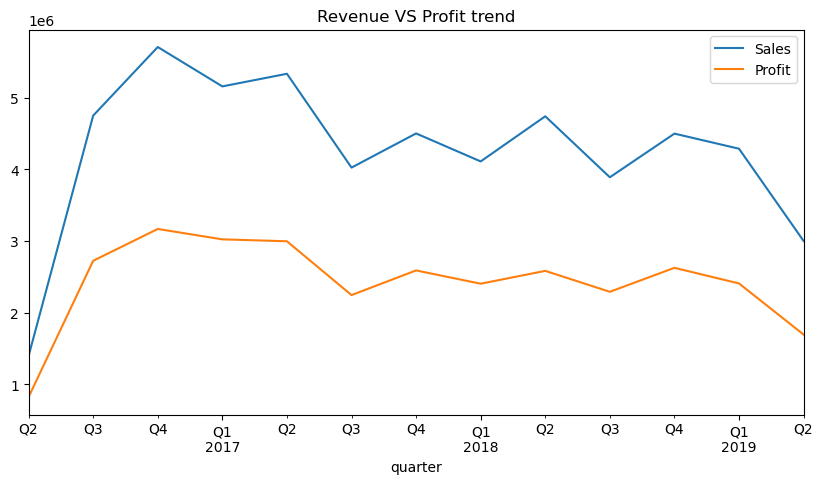

In [28]:
plt.figure(figsize=(10,5))
quarterly_sales.plot(label= 'Sales')
quarterly_profit.plot(label= 'Profit')
plt.legend()
plt.title('Revenue VS Profit trend')
plt.show()

## Revenue vs Profit Trend Insights

For accurate interpretation, partial periods such as 2016 Q2 and 2019 Q2 are excluded from the analysis.

- Revenue and profit generally move in the same direction across quarters, indicating that the business maintains a consistent relationship between sales and profitability at an aggregate level.
- However, profit shows relatively smaller fluctuations compared to revenue, suggesting that while sales vary significantly, profitability is partially stabilized, possibly due to cost controls or pricing consistency.
- The business experiences cyclical patterns, with periods of decline followed by recovery (e.g., 2017 Q3 → 2017 Q4, 2018 Q3 → 2018 Q4), indicating potential seasonality or demand-driven trends.
- Despite alignment, revenue peaks do not always result in proportionally higher profit peaks, suggesting diminishing efficiency at higher sales levels, likely due to increasing costs.
- The overall trend indicates moderate stability rather than strong growth, with revenue and profit fluctuating within a range rather than showing a sustained upward trajectory.
- The declining trend toward early 2019 suggests a potential slowdown phase, where both revenue and profit begin to weaken, indicating possible demand reduction or rising cost pressures.
- Overall, the business demonstrates consistent but not highly scalable growth, with performance influenced by cyclical patterns and cost dynamics.

## Financial Performance Analysis

The growth analysis indicates that revenue expansion is not consistently translating into proportional profit growth. To understand the underlying reasons, the following sections analyze cost structure, efficiency, and sustainability across business segments.

### Cost Structure Analysis

In [29]:
cost_analysis = df.groupby('category').agg({
    'sales' : 'sum',
    'cogs' : 'sum',
    'profit' : 'sum'
})

cost_analysis['cost_ratio'] = cost_analysis['cogs'] / cost_analysis['sales']

cost_analysis = cost_analysis.sort_values(by='cost_ratio', ascending=False)

cost_analysis_m = cost_analysis.copy()

cost_analysis_m['sales']= (cost_analysis_m['sales'] / 1_000_000).round(2)
cost_analysis_m['cogs']= (cost_analysis_m['cogs'] / 1_000_000).round(2)
cost_analysis_m['profit']= (cost_analysis_m['profit'] / 1_000_000).round(2)

cost_analysis_m.round(2)

,sales,cogs,profit,cost_ratio
category,,,,
TV and Video,9.11,4.28,4.82,0.47
Audio,1.03,0.45,0.58,0.44
Cell phones,5.84,2.56,3.29,0.44
Computers,21.31,9.14,12.16,0.43
Cameras and camcorders,17.05,6.95,10.10,0.41
"Music, Movies and Audio Books",1.06,0.42,0.64,0.40


#### Values are represented in millions for better readability.

#### Insights

- Computers and Cameras & Camcorders are the primary revenue and profit drivers, combining scale with strong cost efficiency (~0.41–0.43), indicating well-managed cost structures at high volume.
- TV and Video is the least cost-efficient major category (~0.47), highlighting significant cost pressure and clear opportunity for margin improvement.
- Cell Phones and Audio demonstrate moderate efficiency (~0.44), positioning them as stable but not optimized categories.
- Music, Movies and Audio Books is the most cost-efficient category (~0.40), but its low revenue contribution limits its overall business impact.
- Cost structure, rather than revenue scale, is the key differentiator of profitability across categories, as high-volume categories like Computers still maintain strong efficiency.

Addressing cost inefficiencies in high-impact categories such as TV and Video can significantly improve overall business profitability.

### Sub-category Cost Analysis — TV and Video

This analysis drills down into the TV and Video category to identify which sub-categories are driving higher cost ratios and impacting overall profitability.

Values are represented in millions for better readability.

In [30]:
tv_subcat = (
    df[df['category'] == 'TV and Video']
    .groupby('sub_category').agg({
    'sales' : 'sum',
    'cogs' : 'sum',
    'profit' : 'sum'
    })
)

# Calculate cost ratio
tv_subcat['cost_ratio'] = tv_subcat['cogs'] / tv_subcat['sales']

# Sort
tv_subcat = tv_subcat.sort_values(by='cost_ratio', ascending=False)

# Convert to millions + round
tv_subcat[["sales", "cogs", "profit"]] = (tv_subcat[["sales", "cogs", "profit"]] / 1_000_000).round(2)

tv_subcat.round(3)

,sales,cogs,profit,cost_ratio
sub_category,,,,
Car Video,2.09,1.03,1.07,0.491
VCD & DVD,0.21,0.10,0.11,0.490
Home Theater System,4.74,2.27,2.47,0.479
Televisions,2.06,0.89,1.18,0.429


#### Insights

- Car Video (~0.491) and VCD & DVD (0.490) are the least efficient sub-categories, indicating significant cost pressure relative to their limited revenue contribution.
- Home Theater System, despite being the largest contributor in TV and Video, operates at a relatively high cost ratio (~0.479), making it a major driver of inefficiency at scale.
- Televisions (~0.429) stands out as the most cost-efficient sub-category, suggesting stronger pricing power or better cost control.
- The presence of multiple high cost-ratio sub-categories indicates that inefficiency in TV and Video is structural rather than isolated.
- High revenue does not ensure efficiency — key contributors like Home Theater carry cost pressure, highlighting the need for cost optimization even in top-performing segments.

These findings suggest that improving profitability in the TV and Video category requires targeted cost optimization in high-cost sub-categories (Car Video, Home Theater) to improve overall category efficiency without affecting revenue scale.

### Efficiency Analysis

In [31]:
# Create Metric
df['revenue_per_order'] = df['sales'] / df['quantity']

efficiency = df.groupby('category').agg({
    'profit_per_order': 'mean',
    'revenue_per_order': 'mean',
    'profit': 'sum',
    'sales': 'sum'
})

# Add true margin
efficiency["profit_margin_total"] = efficiency["profit"] / efficiency["sales"]

efficiency["profit_margin_avg"] = df.groupby("category")["profit_margin"].mean()

# convert to millions
efficiency[['sales', 'profit']] = efficiency[['sales', 'profit']] / 1_000_000

efficiency = efficiency.sort_values(by='profit_per_order', ascending = False).round(2)
efficiency

,profit_per_order,revenue_per_order,profit,sales,profit_margin_total,profit_margin_avg
category,,,,,,
Cameras and camcorders,230.56,389.05,10.10,17.05,0.59,0.56
TV and Video,213.85,400.45,4.82,9.11,0.53,0.51
Computers,175.98,305.01,12.16,21.31,0.57,0.53
Cell phones,90.10,161.33,3.29,5.84,0.56,0.54
Audio,63.96,112.30,0.58,1.03,0.56,0.53
"Music, Movies and Audio Books",62.38,103.55,0.64,1.06,0.60,0.57


#### Insights

- Cameras and Camcorders is the most efficient category, generating the highest profit per order (230.56) along with strong revenue per order, and also maintains a high overall profit margin (~0.59), indicating both transactional and aggregate efficiency.
- TV and Video, despite its cost inefficiency identified earlier, shows strong profit per order (213.85) and the highest revenue per order (400.45). Its total profit margin (~0.53) confirms that high transaction value is compensating for its higher cost structure, but not eliminating the inefficiency.
- Computers demonstrates strong and balanced performance, with solid profit per order and a high total margin (~0.57), making it one of the most scalable and efficient categories.
- Cell Phones and Audio maintain moderate efficiency, with decent total margins (~0.56) but relatively low profit per order, indicating a reliance on volume-driven profitability rather than high-value transactions.
- Music, Movies and Audio Books shows the highest total profit margin (~0.60) despite low profit per order, suggesting strong margin efficiency but limited impact due to smaller transaction size and scale.
- The difference between average margin and total margin across categories is relatively small, indicating consistency in pricing and cost structure, and confirming that efficiency differences are primarily driven by transaction size rather than margin distortion.

Improving profitability in lower-efficiency categories will require either increasing transaction value (pricing/upselling) or reducing cost per unit.

### Channel Efficiency Analysis

This analysis evaluates how different sales channels perform in terms of profitability, efficiency, and transaction value to identify the most effective sales strategy.

In [32]:
channel_eff = df.groupby('channel').agg({
    'profit_per_order': 'mean',
    'revenue_per_order': 'mean',
    'profit': 'sum',
    'sales': 'sum'
})

# Derived metrics
channel_eff['profit_margin_total'] = channel_eff['profit'] / channel_eff['sales']

# Convert to millions
channel_eff[['profit', 'sales']] = channel_eff[['profit', 'sales']]/1_000_000

# Rounding
channel_eff = channel_eff.round({
    'profit_per_order': 3,
    'revenue_per_order': 3,
    'profit': 2,
    'sales': 2,
    'profit_margin_total': 3
})

# Sort by profit per order
channel_eff = channel_eff.sort_values(by= 'profit_per_order', ascending = False)

channel_eff

,profit_per_order,revenue_per_order,profit,sales,profit_margin_total
channel,,,,,
Catalog,180.749,305.526,2.90,5.00,0.579
Online,166.734,297.039,6.53,11.50,0.568
Reseller,166.143,286.853,4.11,7.17,0.574
Store,166.117,289.790,18.05,31.72,0.569


#### Insights

- Catalog is the most efficient channel on a per-transaction basis, generating the highest profit per order (~180.75) and maintaining the highest profit margin (0.579), indicating strong pricing power and cost control despite lower overall scale.
- Online channel delivers strong performance with high revenue (~11.50M) and solid efficiency (166.73 profit per order), making it one of the most balanced channels in terms of both scale and profitability.
- Reseller channel shows comparable efficiency to Online and Store, with slightly higher margins (~0.574), suggesting stable and consistent performance without significant inefficiencies.
- Store is the largest channel by a significant margin, contributing the highest revenue (~31.72M) and profit (18.05M), making it the primary driver of business scale, although its efficiency is slightly lower than Catalog.
- Profit margins across all channels are very similar (~0.568–0.579), indicating a consistent pricing and cost structure regardless of sales channel.
- The key difference between channels lies in transaction value and scale rather than margin, with Catalog focusing on high-value transactions and Store dominating through volume.

The business does not rely on a single superior channel but instead benefits from a balanced multi-channel strategy, where Store drives scale, Online provides balanced growth, and Catalog delivers high-value transactions.

## Market Performance Analysis

### Region Analysis

In [33]:
region_perf = df.groupby('region').agg({
    'sales': 'sum',
    'profit': 'sum',
    'cogs': 'sum'
})

# Derived metrics
region_perf['profit_margin_total'] = region_perf['profit'] / region_perf['sales']
region_perf['cost_ratio_total'] = region_perf['cogs'] / region_perf['sales']

# convert to millions
region_perf[['sales', 'profit', 'cogs']] = region_perf[['sales', 'profit', 'cogs']] / 1_000_000

region_perf = region_perf.sort_values(by= 'sales', ascending = False).round(2)

region_perf

,sales,profit,cogs,profit_margin_total,cost_ratio_total
region,,,,,
North America,32.78,18.67,14.11,0.57,0.43
Asia,12.41,7.14,5.27,0.58,0.42
Europe,10.20,5.77,4.42,0.57,0.43


#### Insights

- North America is the dominant market, contributing the highest revenue and profit, making it the primary driver of overall business performance.
- Asia, despite lower total revenue compared to North America, demonstrates the highest profit margin (~0.58) and lowest cost ratio (0.42), indicating superior cost efficiency and strong profitability.
- Europe shows similar performance to North America in terms of margin (~0.57) and cost structure, but operates at a smaller scale, contributing less to total revenue and profit.
- Profit margins and cost ratios are relatively consistent across regions, suggesting that the business model is stable and standardized globally.
- The key difference across regions is driven by scale rather than efficiency, with North America leading in volume while Asia leads in efficiency.

Strategic expansion should prioritize high-efficiency regions like Asia while maintaining dominance in North America for revenue stability.

### Country Analysis

In [34]:
country_perf = df.groupby(['region', 'country']).agg({
    'sales': 'sum',
    'profit': 'sum',
    'cogs': 'sum',
    'order_id': 'count'
})

# Derived metrics
country_perf['profit_margin_total'] = country_perf['profit'] / country_perf['sales']
country_perf['cost_ratio_total'] = country_perf['cogs'] / country_perf['sales']
country_perf['avg_order_value'] = country_perf['sales'] / country_perf['order_id']

# Convert to millions
country_perf[['sales', 'profit', 'cogs']] = country_perf[['sales', 'profit', 'cogs']] / 1_000_000

# Rounding
country_perf = country_perf.round({
    'sales': 2,
    'profit': 2,
    'cogs': 2,
    'profit_margin_total': 3,
    'cost_ratio_total': 3,
    'avg_order_value': 2
})

# Sort by profit
country_perf = country_perf.sort_values(by= 'profit', ascending= False)

country_perf

sales  profit   cogs  order_id  \
region        country                                           
North America United States    31.64   18.00  13.64      8510   
Asia          China             7.56    4.39   3.17      1673   
Europe        Germany           4.31    2.47   1.84      1118   
              France            2.63    1.40   1.23       781   
              United Kingdom    1.32    0.73   0.59       477   
North America Canada            1.15    0.67   0.48       359   
Asia          Japan             0.96    0.56   0.40       298   
              India             0.60    0.36   0.24       152   
              Australia         0.63    0.34   0.29       149   
Europe        Russia            0.43    0.26   0.17       166   
Asia          Turkmenistan      0.41    0.23   0.18       119   
              Iran              0.37    0.19   0.18        89   
              Syria             0.33    0.18   0.15        86   
Europe        Italy             0.32    0.17   0.15       111   
Asia          Pakistan          0.30    0.17   0.13        93   
              Thailand          0.26    0.15   0.11        82   
              South Korea       0.25    0.15   0.10        72   
              Taiwan            0.19    0.11   0.08        50   
              Armenia           0.17    0.11   0.06        44   
Europe        Spain             0.14    0.10   0.04        32   
Asia          Bhutan            0.16    0.09   0.07        48   
Europe        Portugal          0.13    0.08   0.05        38   
              Romania           0.10    0.07   0.04        39   
              Switzerland       0.10    0.07   0.03        35   
              the Netherlands   0.11    0.07   0.04        38   
Asia          Kyrgyzstan        0.13    0.07   0.06        46   
Europe        Malta             0.11    0.06   0.05        41   
              Ireland           0.09    0.06   0.03        37   
              Poland            0.09    0.05   0.04        37   
              Denmark           0.08    0.05   0.03        42   
              Sweden            0.08    0.05   0.03        30   
              Slovenia          0.08    0.04   0.04        34   
Asia          Singapore         0.10    0.04   0.06        49   
Europe        Greece            0.07    0.04   0.03        25   

                               profit_margin_total  cost_ratio_total  \
region        country                                                  
North America United States                  0.569             0.431   
Asia          China                          0.581             0.419   
Europe        Germany                        0.573             0.427   
              France                         0.533             0.467   
              United Kingdom                 0.551             0.449   
North America Canada                         0.582             0.418   
Asia          Japan                          0.579             0.421   
              India                          0.598             0.402   
              Australia                      0.544             0.456   
Europe        Russia                         0.603             0.397   
Asia          Turkmenistan                   0.557             0.443   
              Iran                           0.523             0.477   
              Syria                          0.543             0.457   
Europe        Italy                          0.539             0.461   
Asia          Pakistan                       0.571             0.429   
              Thailand                       0.588             0.412   
              South Korea                    0.601             0.399   
              Taiwan                         0.578             0.422   
              Armenia                        0.647             0.353   
Europe        Spain                          0.720             0.280   
Asia          Bhutan                         0.547             0.453   
Europe        Portugal            

#### Insights

- The United States is the dominant market by a significant margin, contributing the highest revenue (~31.64M), profit (18.00M), and order volume, making it the backbone of overall business performance.
- China stands out as the strongest international growth market, with high revenue (7.56M), strong profit (4.39M), the highest average order value (~4517), and solid margins (0.58), indicating both scale and efficiency.
- Germany and France are key contributors within Europe, but France shows relatively lower margin (~0.53) and higher cost ratio (0.47), indicating potential cost inefficiencies compared to Germany.
- India and several Asian countries (e.g., South Korea, Taiwan) demonstrate high profit margins (~0.58–0.60) along with strong average order values, suggesting high efficiency but currently limited scale, making them strong expansion opportunities.
- Canada and Japan show balanced performance with good margins and moderate scale, acting as stable secondary markets.
- Some countries such as Iran and France exhibit higher cost ratios (~0.47), indicating potential inefficiencies that may require pricing or cost optimization.
- Smaller European markets (e.g., Spain, Switzerland, Ireland) demonstrate strong margins and efficiency but contribute less overall revenue, indicating niche but profitable markets.
- Overall, market performance varies more in terms of scale than efficiency, with most countries maintaining relatively consistent margins, reinforcing the strength of the underlying business model.

The business is heavily dependent on North America for scale, while Asian markets demonstrate higher efficiency and average order values, indicating strong potential for profitable expansion. Scaling high-margin but low-volume markets (e.g., India, South Korea) can improve overall profitability without significantly increasing cost pressure.

## Sustainability Analysis

This analysis evaluates the consistency of profitability across categories to identify stable versus volatile business segments.

In [35]:
stability = df.groupby('category')['profit'].std().sort_values()

stability = stability.reset_index().round(2)
stability

,category,profit
0,Audio,992.96
1,"Music, Movies and Audio Books",1000.55
2,Cell phones,1763.11
3,TV and Video,3195.37
4,Cameras and camcorders,3621.50
5,Computers,4080.19


#### Insights

- Audio and Music, Movies and Audio Books are the most stable categories, with the lowest profit variability, indicating consistent but relatively low-scale performance. These categories provide reliability but limited growth impact.
- Cell Phones demonstrates moderate stability, balancing reasonable consistency with mid-level efficiency, making it a dependable but not high-impact category.
- TV and Video shows higher volatility (~3195), which aligns with its previously identified high cost structure and high transaction value. This suggests that while the category generates strong revenue and profit per order, its performance is less predictable and more sensitive to cost fluctuations.
- Cameras and Camcorders, despite being the most efficient category with the highest profit per order, also exhibits high variability (~3621), indicating that strong profitability comes with increased volatility.
- Computers shows the highest volatility (~4080), even though it maintains strong efficiency and high overall profitability. This suggests that its performance may be driven by fluctuating demand or pricing, making it a high-return but high-risk category.
- Overall, there is a clear trade-off between efficiency and stability: categories with higher profit potential (Computers, Cameras, TV and Video) tend to be more volatile, while more stable categories (Audio, Music-related) contribute less to overall profitability.

High-performing but volatile categories require risk management strategies such as demand forecasting and pricing stabilization to ensure consistent profitability.

## Supporting Visualizations

### Cost Ratio Trend

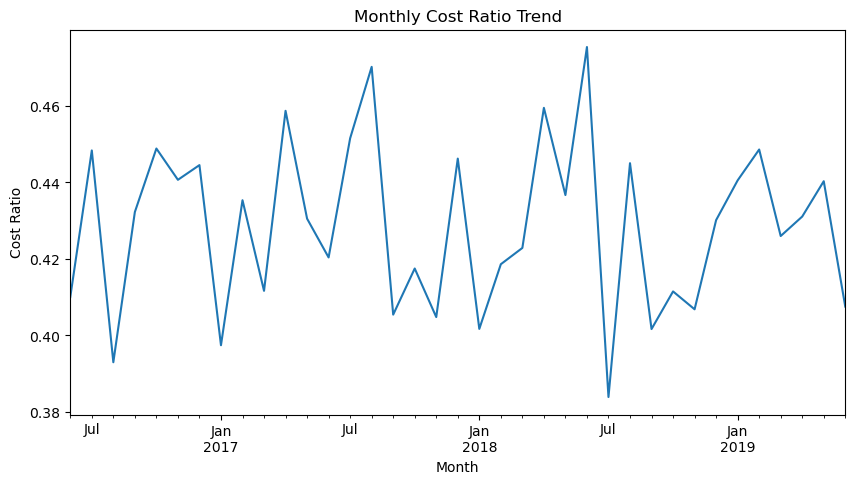

In [36]:
monthly = df.groupby('month').agg({
    'cogs': 'sum',
    'sales': 'sum'
})

monthly['cost_ratio'] = monthly['cogs'] / monthly['sales']

plt.figure(figsize= (10,5))

monthly['cost_ratio'].plot()

plt.title('Monthly Cost Ratio Trend')
plt.xlabel('Month')
plt.ylabel('Cost Ratio')

plt.show()

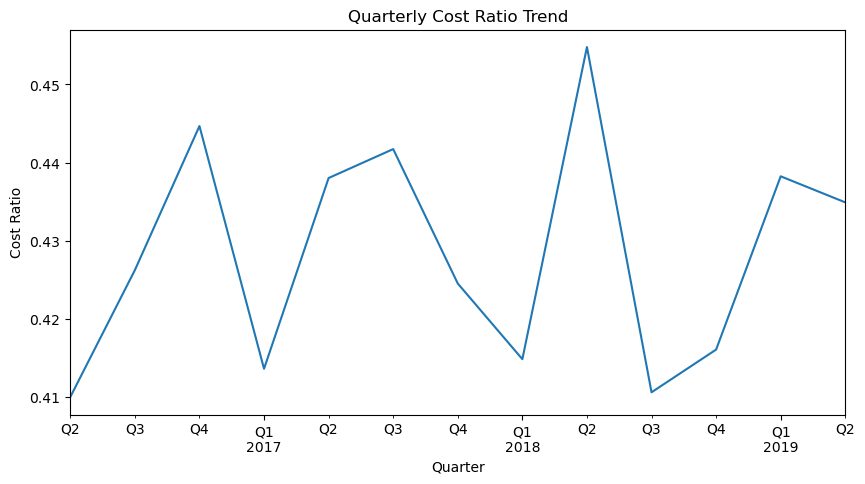

In [37]:
quarterly = df.groupby('quarter').agg({
    'cogs': 'sum',
    'sales': 'sum'
})

quarterly['cost_ratio'] = quarterly['cogs'] / quarterly['sales']

plt.figure(figsize =(10,5))

quarterly['cost_ratio'].plot()

plt.title('Quarterly Cost Ratio Trend')
plt.xlabel('Quarter')
plt.ylabel('Cost Ratio')

plt.show()

### Cost Structure by Category

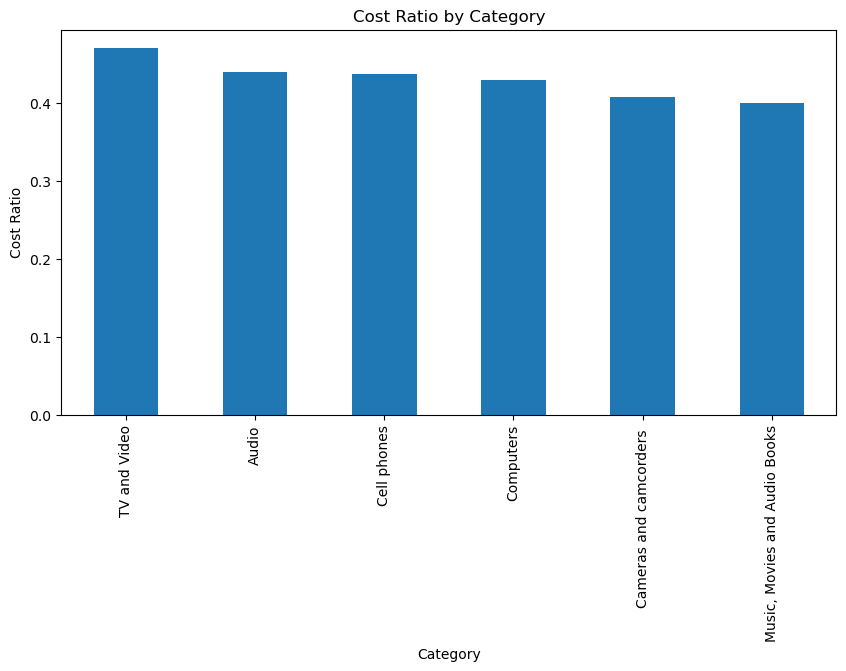

In [38]:
plt.figure(figsize =(10,5))

sorted_data = cost_analysis_m.sort_values('cost_ratio', ascending = False)

sorted_data['cost_ratio'].plot(kind = 'bar')

plt.title('Cost Ratio by Category')
plt.xlabel('Category')
plt.ylabel('Cost Ratio')

plt.show()

### Category-wise Efficiency (Profit per Order)

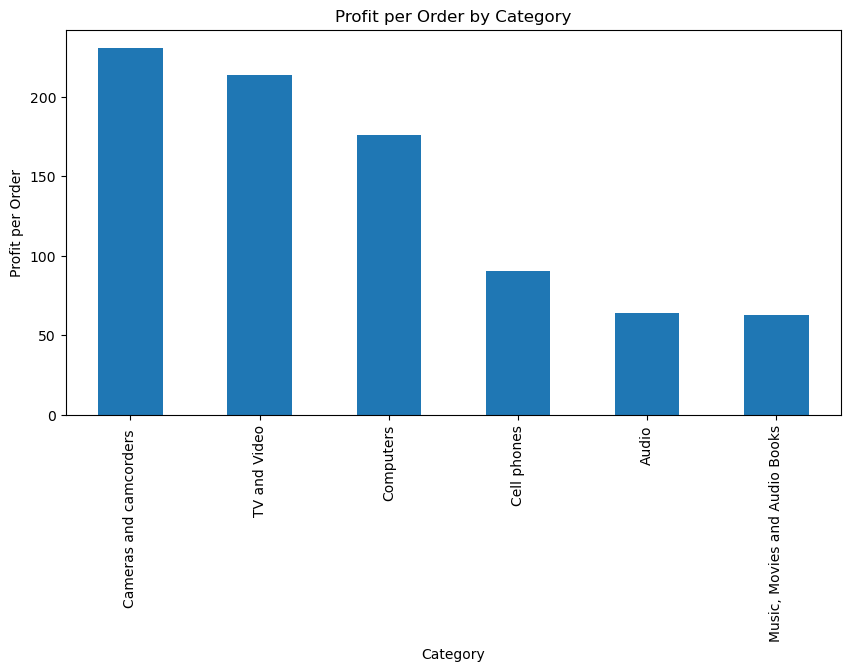

In [39]:
plt.figure(figsize=(10,5))

efficiency = efficiency.sort_values(by='profit_per_order', ascending=False)

efficiency["profit_per_order"].plot(kind="bar")

plt.title("Profit per Order by Category")
plt.xlabel("Category")
plt.ylabel("Profit per Order")

plt.show()

### Channel-wise Efficiency (Profit per Order)

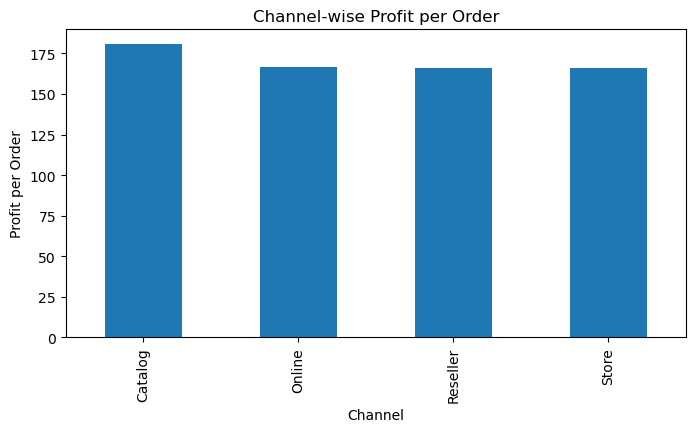

In [40]:
plt.figure(figsize=(8,4))

channel_eff["profit_per_order"].plot(kind="bar")

plt.title("Channel-wise Profit per Order")
plt.xlabel("Channel")
plt.ylabel("Profit per Order")

plt.show()

### Regional Profit Contribution

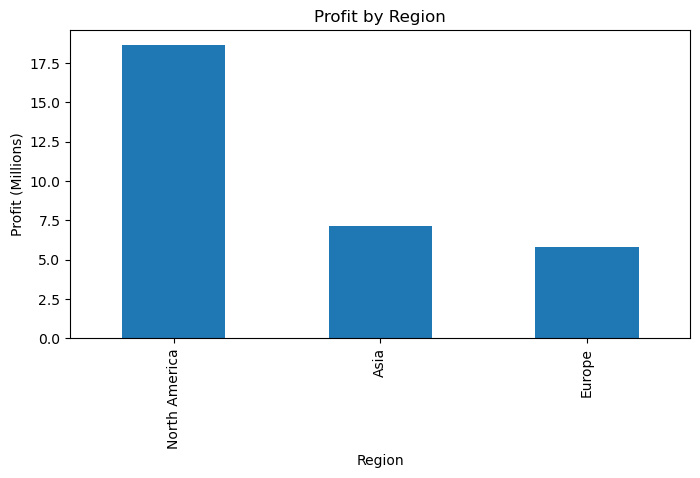

In [41]:
plt.figure(figsize=(8,4))

region_perf.sort_values(by= "profit", ascending= False)["profit"].plot(kind= "bar")

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit (Millions)")

plt.show()

#### Visualization Insights

- Profit distribution across regions confirms that North America is the dominant revenue and profit contributor, reinforcing its role as the primary scale driver, while Asia and Europe contribute significantly less but maintain comparable efficiency levels.

- Channel-wise performance shows minimal variation in profit per order, indicating a consistent and well-balanced multi-channel strategy where differences are driven more by scale than efficiency.

- Category-level efficiency highlights a clear gap between high-value and low-value segments, with Cameras and Camcorders and TV and Video generating significantly higher profit per order, while Audio and Music-related categories operate on lower transaction value.

- Cost ratio comparison across categories reinforces earlier findings that TV and Video operates under higher cost pressure, while categories like Music and Cameras maintain stronger cost efficiency.

- Time-based cost ratio trends (monthly and quarterly) indicate moderate fluctuations without a clear long-term upward or downward trend, suggesting that cost structure is relatively stable but subject to periodic variability.

- Overall, the visualizations confirm that differences in performance are driven more by structural factors (category mix, transaction value, and market scale) rather than drastic changes over time.

## Final Insights & Recommendations

### Key Insights

- The business demonstrates revenue growth, but this growth is not consistently translating into proportional profit due to structural cost inefficiencies across key categories.
- Cost structure is the primary driver of profitability differences, with categories like TV and Video operating under higher cost pressure, while Computers and Cameras maintain efficient margins at scale.
- Efficiency differences are driven more by transaction value than margin variation, with high-performing categories generating significantly higher profit per order.
- The business follows a balanced multi-channel strategy, where Store drives scale, Online supports growth, and Catalog contributes high-value transactions.
- Market performance is heavily concentrated in North America, while Asian markets demonstrate strong efficiency and higher average order values, indicating expansion potential.
- High-performing categories such as Computers and Cameras deliver strong profitability but exhibit higher volatility, indicating a trade-off between growth and stability.

### Business Recommendations

- Optimize cost structure in TV and Video, particularly in high-revenue sub-categories such as Home Theater, to improve overall profitability.
- Focus on scaling high-efficiency categories such as Computers and Cameras, as they combine strong margins with high revenue potential.
- Expand presence in high-efficiency markets such as Asia, where strong margins and higher transaction values indicate growth opportunities.
- Maintain Store channel as the primary revenue driver while strengthening Online channels to support scalable and cost-effective growth.
- Leverage Catalog channel for premium, high-value transactions, ensuring it remains optimized for profitability rather than volume.
- Monitor volatility in high-performing categories and implement strategies to stabilize performance, such as demand forecasting and pricing optimization.

### Final Conclusion

The business demonstrates a strong and scalable model supported by a balanced product mix, multi-channel strategy, and global presence. However, profitability is influenced more by cost structure than revenue growth, with certain categories operating under higher cost pressure. While high-performing segments drive growth, they also introduce variability, indicating a trade-off between profitability and stability. Overall, the business is fundamentally strong but requires targeted cost optimization and strategic expansion in high-efficiency markets to achieve sustainable and consistent growth.

Achieving long-term sustainability will depend on improving cost efficiency in high-impact categories while scaling high-margin markets and maintaining a balanced channel strategy.